In [1]:
# Problema: Decidir a qué ciudad reasentar a cada familia refugiada, respetando cupos y compatibilidades, para maximizar las perspectivas estimadas de empleo del conjunto de familias.
# El taller comienza donde termina la predicción: elegimos combinaciones compatibles.

from pathlib import Path
from itertools import product
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import pulp

data_dir = Path('../data')
submission_dir = Path('../submission')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
display(['families.csv', 'locations.csv', 'predicted_outcomes.csv'])

['families.csv', 'locations.csv', 'predicted_outcomes.csv']

In [2]:
# Caso sintético: empleo de al menos un adulto en seis meses, no bienestar integral.

families = pd.read_csv(data_dir / 'families.csv').sort_values('family_id')
locations = pd.read_csv(data_dir / 'locations.csv').sort_values('location_id')
predictions = pd.read_csv(data_dir / 'predicted_outcomes.csv')
display(families, locations, predictions)

,family_id,service_requirement
0,F01,none
1,F02,none
2,F03,none
3,F04,none
4,F05,none
5,F06,none
6,F07,none
7,F08,service_A


,location_id,capacity,available_service
0,L01,2,service_A
1,L02,2,none
2,L03,2,none
3,L04,2,service_A


,family_id,location_id,employment_probability
0,F01,L01,0.80
1,F01,L02,0.55
2,F01,L03,0.50
3,F01,L04,0.78
4,F02,L01,0.86
5,F02,L02,0.52
6,F02,L03,0.48
7,F02,L04,0.55
8,F03,L01,0.60
9,F03,L02,0.84


In [3]:
# La compatibilidad depende del servicio requerido, nunca de una probabilidad vacía.

pairs = predictions.merge(families, on='family_id', validate='many_to_one').merge(locations, on='location_id', validate='many_to_one')
pairs['compatible'] = pairs.service_requirement.eq('none') | pairs.service_requirement.eq(pairs.available_service)
display(pairs.loc[pairs.family_id == 'F08', ['family_id', 'location_id', 'service_requirement', 'available_service', 'compatible', 'employment_probability']])

,family_id,location_id,service_requirement,available_service,compatible,employment_probability
28,F08,L01,service_A,service_A,True,0.88
29,F08,L02,service_A,none,False,NaN
30,F08,L03,service_A,none,False,NaN
31,F08,L04,service_A,service_A,True,0.50


In [4]:
# Una pareja prohibida es distinta de una alternativa con baja probabilidad.

family_ids = families.family_id.tolist()
location_ids = locations.location_id.tolist()
capacity = locations.set_index('location_id').capacity
assert len(families) == 8 and families.family_id.is_unique
assert len(locations) == 4 and locations.location_id.is_unique and capacity.sum() == 8
assert len(pairs) == 32 and not pairs.duplicated(['family_id', 'location_id']).any()
assert set(zip(pairs.family_id, pairs.location_id)) == set(product(family_ids, location_ids))
assert pairs.loc[pairs.compatible, 'employment_probability'].between(0, 1).all()
assert pairs.loc[~pairs.compatible, 'employment_probability'].isna().all()
assert pairs.loc[(pairs.family_id == 'F08') & pairs.compatible, 'location_id'].tolist() == ['L01', 'L04']
feasible_pairs = pairs[pairs.compatible].copy()
display(pd.Series({'parejas_compatibles': len(feasible_pairs), 'parejas_incompatibles': (~pairs.compatible).sum()}))

parejas_compatibles      30
parejas_incompatibles     2
dtype: int64

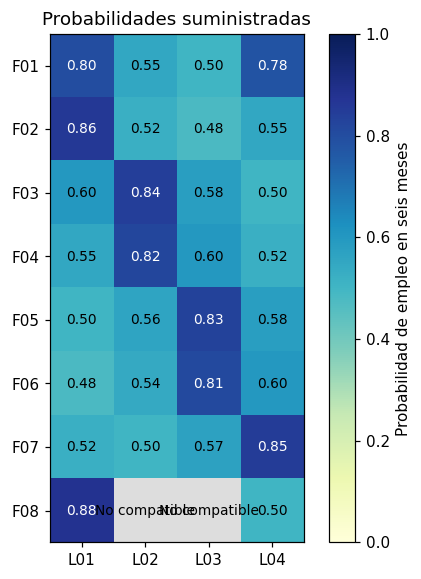

In [5]:
# Cada casilla evalúa una alternativa; todavía no seleccionamos un plan conjunto.

probability_matrix = pairs.pivot(index='family_id', columns='location_id', values='employment_probability').reindex(index=family_ids, columns=location_ids)
compatibility_matrix = pairs.pivot(index='family_id', columns='location_id', values='compatible').reindex(index=family_ids, columns=location_ids)
cmap = plt.colormaps['YlGnBu'].copy()
cmap.set_bad('#dddddd')
fig, ax = plt.subplots(figsize=(6, 6))
mesh = ax.imshow(np.ma.masked_invalid(probability_matrix.to_numpy()), vmin=0, vmax=1, cmap=cmap)
for i, f in enumerate(family_ids):
    for j, l in enumerate(location_ids):
        label = f'{probability_matrix.loc[f, l]:.2f}' if compatibility_matrix.loc[f, l] else 'No compatible'
        ax.text(j, i, label, ha='center', va='center', fontsize=9, color='white' if probability_matrix.loc[f, l] > 0.7 else 'black')
ax.set(xticks=range(4), xticklabels=location_ids, yticks=range(8), yticklabels=family_ids, title='Probabilidades suministradas')
fig.colorbar(mesh, ax=ax, label='Probabilidad de empleo en seis meses')
plt.show()

In [6]:
# Elegimos máximos individuales compatibles; los empates se resuelven por localidad.

ranked = feasible_pairs.sort_values(['family_id', 'employment_probability', 'location_id'], ascending=[True, False, True])
individual = ranked.drop_duplicates('family_id').set_index('family_id')[['location_id', 'employment_probability']].reindex(family_ids)
display(individual)

,location_id,employment_probability
family_id,,
F01,L01,0.80
F02,L01,0.86
F03,L02,0.84
F04,L02,0.82
F05,L03,0.83
F06,L03,0.81
F07,L04,0.85
F08,L01,0.88


In [7]:
# La suma es un número esperado de familias; no una probabilidad del grupo.

individual_total = individual.employment_probability.sum()
print(f'Referencia individual sin capacidad compartida: {individual_total:.2f}')

Referencia individual sin capacidad compartida: 6.69


,capacity,assigned_cases,excess
location_id,,,
L01,2,3,1
L02,2,2,0
L03,2,2,0
L04,2,1,0


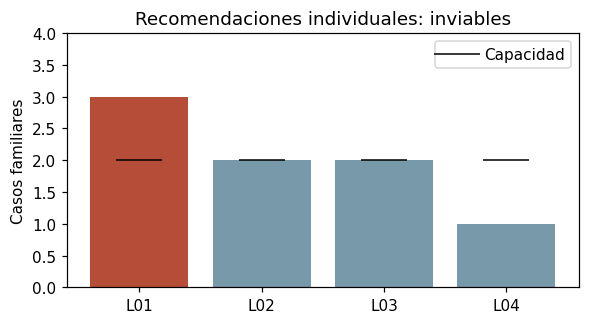

In [8]:
# Esta referencia no es ejecutable: tres familias compiten por dos plazas en L01.

individual_usage = individual.location_id.value_counts().reindex(location_ids, fill_value=0)
individual_capacity = pd.DataFrame({'capacity': capacity, 'assigned_cases': individual_usage})
individual_capacity['excess'] = (individual_capacity.assigned_cases - individual_capacity.capacity).clip(lower=0)
display(individual_capacity)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(location_ids, individual_usage, color=['#b64d39', '#7799aa', '#7799aa', '#7799aa'])
ax.plot(location_ids, capacity, 'k_', markersize=30, label='Capacidad')
ax.set(ylabel='Casos familiares', title='Recomendaciones individuales: inviables', ylim=(0, 4))
ax.legend()
plt.show()

In [9]:
# Cada elección secuencial reduce las opciones de las familias siguientes.

remaining = capacity.to_dict()
greedy_rows = []
capacity_history = []
for family in family_ids:
    options = ranked[(ranked.family_id == family) & ranked.location_id.map(remaining).gt(0)]
    assert not options.empty
    chosen = options.iloc[0]
    capacity_history.append({'family_id': family, **{f'{l}_before': remaining[l] for l in location_ids}})
    remaining[chosen.location_id] -= 1
    capacity_history[-1].update({f'{l}_after': remaining[l] for l in location_ids})
    greedy_rows.append([family, chosen.location_id, chosen.employment_probability])
sequential = pd.DataFrame(greedy_rows, columns=['family_id', 'location_id', 'employment_probability']).set_index('family_id')
display(sequential)

,location_id,employment_probability
family_id,,
F01,L01,0.80
F02,L01,0.86
F03,L02,0.84
F04,L02,0.82
F05,L03,0.83
F06,L03,0.81
F07,L04,0.85
F08,L04,0.50


,L01_before,L02_before,L03_before,L04_before,L01_after,L02_after,L03_after,L04_after
family_id,,,,,,,,
F01,2,2,2,2,1,2,2,2
F02,1,2,2,2,0,2,2,2
F03,0,2,2,2,0,1,2,2
F04,0,1,2,2,0,0,2,2
F05,0,0,2,2,0,0,1,2
F06,0,0,1,2,0,0,0,2
F07,0,0,0,2,0,0,0,1
F08,0,0,0,1,0,0,0,0


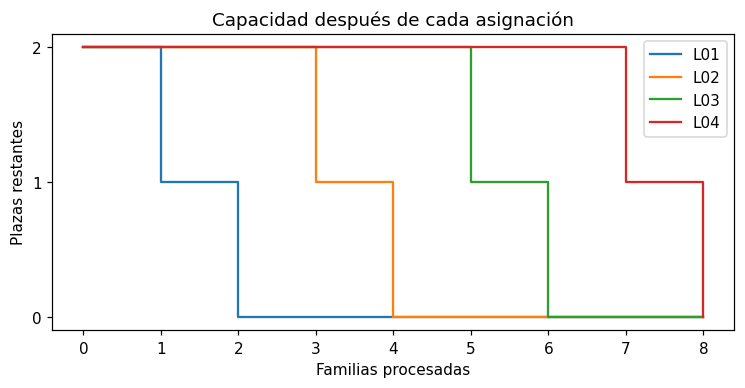

In [10]:
# El orden administrativo determina quién encuentra plazas todavía disponibles.

history = pd.DataFrame(capacity_history).set_index('family_id')
display(history)
fig, ax = plt.subplots(figsize=(8, 3.5))
for location in location_ids:
    ax.step(range(9), [capacity[location]] + history[f'{location}_after'].tolist(), where='post', label=location)
ax.set(xlabel='Familias procesadas', ylabel='Plazas restantes', title='Capacidad después de cada asignación', yticks=[0, 1, 2])
ax.legend()
plt.show()

In [11]:
# Una solución completa y factible puede ser inferior a otra combinación.

sequential_total = sequential.employment_probability.sum()
sequential_usage = sequential.location_id.value_counts().reindex(location_ids, fill_value=0)
assert len(sequential) == 8 and sequential_usage.le(capacity).all()
assert all(compatibility_matrix.loc[f, l] for f, l in sequential.location_id.items())
print(f'Resultado secuencial factible: {sequential_total:.2f}')

Resultado secuencial factible: 6.31


In [12]:
# F08 llega cuando L01 ya está lleno, aunque allí su probabilidad es mayor.

f08_options = feasible_pairs[feasible_pairs.family_id == 'F08'][['location_id', 'employment_probability']].copy()
f08_options['remaining_before_F08'] = f08_options.location_id.map({l: history.loc['F08', f'{l}_before'] for l in location_ids})
display(f08_options, sequential.loc[['F08']])

,location_id,employment_probability,remaining_before_F08
28,L01,0.88,0
31,L04,0.50,1


,location_id,employment_probability
family_id,,
F08,L04,0.5


In [13]:
# x[f,l] = 1 selecciona la pareja; cada familia debe conservarse indivisible.

x_sequential = pd.DataFrame(0, index=family_ids, columns=location_ids)
for family, location in sequential.location_id.items():
    x_sequential.loc[family, location] = 1
display(x_sequential)

,L01,L02,L03,L04
F01,1,0,0,0
F02,1,0,0,0
F03,0,1,0,0
F04,0,1,0,0
F05,0,0,1,0
F06,0,0,1,0
F07,0,0,0,1
F08,0,0,0,1


In [14]:
# Objetivo: maximizar sum(p[f,l] * x[f,l]) sobre parejas compatibles.
# No reemplazamos incompatibilidad por probabilidad cero.

selected_terms = feasible_pairs[['family_id', 'location_id', 'employment_probability']].copy()
selected_terms['x'] = [x_sequential.loc[f, l] for f, l in zip(selected_terms.family_id, selected_terms.location_id)]
selected_terms['contribution'] = selected_terms.employment_probability * selected_terms.x
display(selected_terms[selected_terms.x == 1])
print(f'Objetivo de la matriz secuencial: {selected_terms.contribution.sum():.2f}')

,family_id,location_id,employment_probability,x,contribution
0,F01,L01,0.80,1,0.80
4,F02,L01,0.86,1,0.86
9,F03,L02,0.84,1,0.84
13,F04,L02,0.82,1,0.82
18,F05,L03,0.83,1,0.83
22,F06,L03,0.81,1,0.81
27,F07,L04,0.85,1,0.85
31,F08,L04,0.50,1,0.50


Objetivo de la matriz secuencial: 6.31


In [15]:
# Tres restricciones: una localidad por familia, capacidad y ninguna pareja incompatible.

assert x_sequential.isin([0, 1]).all().all()
assert x_sequential.sum(axis=1).eq(1).all()
assert x_sequential.sum(axis=0).le(capacity).all()
assert x_sequential.where(~compatibility_matrix, 0).eq(0).all().all()
display(pd.DataFrame({'used': x_sequential.sum(), 'capacity': capacity}))

,used,capacity
L01,2,2
L02,2,2
L03,2,2
L04,2,2


In [16]:
# Enumeración transparente: partimos de opciones compatibles por familia, no de las combinaciones crudas.

compatible_options = {f: sorted(feasible_pairs.loc[feasible_pairs.family_id == f, 'location_id']) for f in family_ids}
# Centésimas enteras permiten comparar exactamente estas probabilidades de dos decimales.
probability_units = {(r.family_id, r.location_id): int(round(100 * r.employment_probability)) for r in feasible_pairs.itertuples()}
raw_assignment_count = len(location_ids) ** len(family_ids)
combination_count = np.prod([len(compatible_options[f]) for f in family_ids])
display(compatible_options)
print(f'{raw_assignment_count:,} asignaciones crudas (4^8) -> {combination_count:,} candidatas compatibles')
print('Escalabilidad: 8 familias, 4 localidades -> 4^8 = 65,536; 20 familias, 4 localidades -> 4^20 > 10^12')

{'F01': ['L01', 'L02', 'L03', 'L04'],
 'F02': ['L01', 'L02', 'L03', 'L04'],
 'F03': ['L01', 'L02', 'L03', 'L04'],
 'F04': ['L01', 'L02', 'L03', 'L04'],
 'F05': ['L01', 'L02', 'L03', 'L04'],
 'F06': ['L01', 'L02', 'L03', 'L04'],
 'F07': ['L01', 'L02', 'L03', 'L04'],
 'F08': ['L01', 'L04']}

65,536 asignaciones crudas (4^8) -> 32,768 candidatas compatibles
Escalabilidad: 8 familias, 4 localidades -> 4^8 = 65,536; 20 familias, 4 localidades -> 4^20 > 10^12


In [17]:
# Evaluamos todas las combinaciones factibles con las mismas predicciones.

feasible_assignments = []
for assignment in product(*(compatible_options[f] for f in family_ids)):
    usage = Counter(assignment)
    if any(usage[l] > capacity[l] for l in location_ids):
        continue
    units = sum(probability_units[f, l] for f, l in zip(family_ids, assignment))
    feasible_assignments.append((units, assignment))
feasible_assignments.sort(key=lambda item: (-item[0], item[1]))
best_units, best_assignment = feasible_assignments[0]
optimized_total = best_units / 100
exhaustive_objective = optimized_total
print(f'{len(feasible_assignments)} asignaciones factibles; mejor objetivo: {optimized_total:.2f}')

1260 asignaciones factibles; mejor objetivo: 6.67


In [18]:
# La unicidad se verifica sobre todas las soluciones, no por la primera encontrada.

optimal_count = sum(units == best_units for units, assignment in feasible_assignments)
second_best = feasible_assignments[1][0] / 100
optimized = pd.DataFrame({'family_id': family_ids, 'location_id': best_assignment}).set_index('family_id')
optimized['employment_probability'] = [probability_matrix.loc[f, l] for f, l in optimized.location_id.items()]
exhaustive_assignment = optimized.location_id.to_dict()
display(optimized)
print(f'Óptimos: {optimal_count}; segundo mejor objetivo: {second_best:.2f}')

,location_id,employment_probability
family_id,,
F01,L04,0.78
F02,L01,0.86
F03,L02,0.84
F04,L02,0.82
F05,L03,0.83
F06,L03,0.81
F07,L04,0.85
F08,L01,0.88


Óptimos: 1; segundo mejor objetivo: 6.38


In [19]:
# MODEL
# ---------------------------------------------------------------------
# Sets:
#   f in FAMILIES
#   l in LOCATIONS
#
# Parameters:
#   p[f,l]             predicted employment probability
#   capacity[l]        family-case capacity at location l
#   compatible[f,l]    1 if assignment is allowed, 0 otherwise
#
# Decision variable:
#   x[f,l] binary
#
# Objective:
#   maximize expected_outcome:
#       sum{f in FAMILIES, l in LOCATIONS}
#           p[f,l] * x[f,l]
#
# Constraints:
#   subject to one_location{f in FAMILIES}:
#       sum{l in LOCATIONS} x[f,l] = 1
#
#   subject to capacity_limit{l in LOCATIONS}:
#       sum{f in FAMILIES} x[f,l] <= capacity[l]
#
#   subject to compatibility{f in FAMILIES, l in LOCATIONS}:
#       x[f,l] <= compatible[f,l]

model = pulp.LpProblem('refugee_placement', pulp.LpMaximize)
x = {(f, l): pulp.LpVariable(f'x_{f}_{l}', cat='Binary') for f in family_ids for l in location_ids}
model += pulp.lpSum(probability_matrix.loc[f, l] * x[f, l] for f in family_ids for l in location_ids if compatibility_matrix.loc[f, l])
for f in family_ids:
    model += pulp.lpSum(x[f, l] for l in location_ids) == 1
for l in location_ids:
    model += pulp.lpSum(x[f, l] for f in family_ids) <= capacity[l]
for f in family_ids:
    for l in location_ids:
        model += x[f, l] <= int(compatibility_matrix.loc[f, l])
display(pd.Series({'variables': len(x), 'one_location_constraints': len(family_ids), 'capacity_constraints': len(location_ids), 'compatibility_constraints': len(x)}))

variables                    32
one_location_constraints      8
capacity_constraints          4
compatibility_constraints    32
dtype: int64

In [20]:
# Resolvemos el mismo modelo con un solver profesional en lugar de enumeración.

solver = pulp.HiGHS(msg=False)
status = model.solve(solver)
assert pulp.LpStatus[status] == 'Optimal'
solver_objective = round(pulp.value(model.objective), 2)
solver_pairs = [(f, l) for f in family_ids for l in location_ids if x[f, l].value() > 0.5]
solver_assignment = {f: l for f, l in solver_pairs}
display(
    pd.DataFrame(
        solver_pairs,
        columns=["family_id", "location_id"],
    ).assign(x=1)
)
print(f'Estado: {pulp.LpStatus[status]}; objetivo HiGHS: {solver_objective:.2f}; parejas seleccionadas: {len(solver_pairs)}')

,family_id,location_id,x
0,F01,L04,1
1,F02,L01,1
2,F03,L02,1
3,F04,L02,1
4,F05,L03,1
5,F06,L03,1
6,F07,L04,1
7,F08,L01,1


Estado: Optimal; objetivo HiGHS: 6.67; parejas seleccionadas: 8


In [21]:
# La búsqueda exhaustiva expone el espacio de decisiones; el solver la resuelve de forma escalable.

solver_usage = pd.Series(solver_assignment).value_counts().reindex(location_ids, fill_value=0)
assert np.isclose(solver_objective, exhaustive_objective)
assert solver_assignment == exhaustive_assignment
assert set(solver_assignment) == set(family_ids) and len(solver_assignment) == len(family_ids)
assert solver_usage.eq(capacity).all()
assert all(compatibility_matrix.loc[f, l] for f, l in solver_assignment.items())
print(f'Exhaustive search objective : {exhaustive_objective:.2f}')
print(f'HiGHS objective             : {solver_objective:.2f}')
print(f'Assignments agree           : {solver_assignment == exhaustive_assignment}')
print(f'Solver status               : {pulp.LpStatus[status]}')

Exhaustive search objective : 6.67
HiGHS objective             : 6.67
Assignments agree           : True
Solver status               : Optimal


In [22]:
# Comparamos decisiones individuales dentro de dos planes factibles.

placement_decisions = individual.rename(columns={'location_id': 'individual_location_id', 'employment_probability': 'individual_best_probability'}).join(sequential.rename(columns={'location_id': 'sequential_location_id', 'employment_probability': 'sequential_probability'})).join(optimized.rename(columns={'location_id': 'optimized_location_id', 'employment_probability': 'optimized_probability'}))
placement_decisions['probability_change'] = placement_decisions.optimized_probability - placement_decisions.sequential_probability
display(placement_decisions)

,individual_location_id,individual_best_probability,sequential_location_id,sequential_probability,optimized_location_id,optimized_probability,probability_change
family_id,,,,,,,
F01,L01,0.80,L01,0.80,L04,0.78,-0.02
F02,L01,0.86,L01,0.86,L01,0.86,0.00
F03,L02,0.84,L02,0.84,L02,0.84,0.00
F04,L02,0.82,L02,0.82,L02,0.82,0.00
F05,L03,0.83,L03,0.83,L03,0.83,0.00
F06,L03,0.81,L03,0.81,L03,0.81,0.00
F07,L04,0.85,L04,0.85,L04,0.85,0.00
F08,L01,0.88,L04,0.50,L01,0.88,0.38


,sequential_location_id,optimized_location_id,sequential_probability,optimized_probability,probability_change
family_id,,,,,
F01,L01,L04,0.8,0.78,-0.02
F08,L04,L01,0.5,0.88,0.38


Ganancia conjunta: 0.36 = 0.38 - 0.02


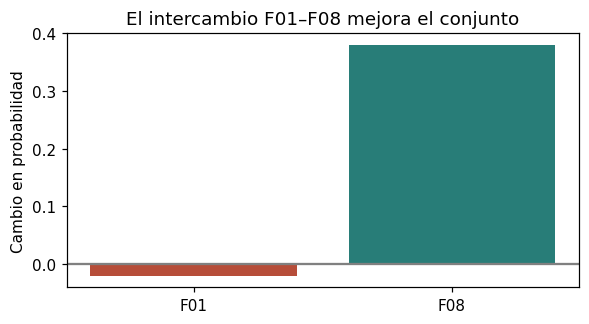

In [23]:
# F01 tiene una alternativa casi equivalente; F08 pierde mucho fuera de L01.

exchange = placement_decisions.loc[['F01', 'F08'], ['sequential_location_id', 'optimized_location_id', 'sequential_probability', 'optimized_probability', 'probability_change']]
display(exchange)
print(f'Ganancia conjunta: {optimized_total - sequential_total:.2f} = 0.38 - 0.02')
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(exchange.index, exchange.probability_change, color=['#b64d39', '#287d78'])
ax.axhline(0, color='gray')
ax.set(ylabel='Cambio en probabilidad', title='El intercambio F01–F08 mejora el conjunto')
plt.show()

In [24]:
# Ninguna predicción cambió: solo cambió la combinación seleccionada.

usage_rows, comparison_rows = [], []
for policy, table in [('individual', individual), ('sequential', sequential), ('optimized', optimized)]:
    counts = table.location_id.value_counts().reindex(location_ids, fill_value=0)
    for l in location_ids:
        usage_rows.append([policy, l, capacity[l], counts[l], capacity[l] - counts[l], max(counts[l] - capacity[l], 0), counts[l] / capacity[l]])
    incompatible = sum(not compatibility_matrix.loc[f, l] for f, l in table.location_id.items())
    excess = (counts - capacity).clip(lower=0).sum()
    feasible = len(table) == len(families) and table.index.is_unique and incompatible == 0 and excess == 0
    comparison_rows.append([policy, len(table), incompatible, excess, feasible, table.employment_probability.sum()])
location_utilization = pd.DataFrame(usage_rows, columns=['policy', 'location_id', 'capacity', 'assigned_cases', 'remaining_capacity', 'capacity_excess', 'utilization_rate'])
assignment_comparison = pd.DataFrame(comparison_rows, columns=['policy', 'assigned_families', 'incompatible_assignments', 'capacity_excess', 'feasible', 'total_expected_outcome'])
display(location_utilization, assignment_comparison)

,policy,location_id,capacity,assigned_cases,remaining_capacity,capacity_excess,utilization_rate
0,individual,L01,2,3,-1,1,1.5
1,individual,L02,2,2,0,0,1.0
2,individual,L03,2,2,0,0,1.0
3,individual,L04,2,1,1,0,0.5
4,sequential,L01,2,2,0,0,1.0
5,sequential,L02,2,2,0,0,1.0
6,sequential,L03,2,2,0,0,1.0
7,sequential,L04,2,2,0,0,1.0
8,optimized,L01,2,2,0,0,1.0
9,optimized,L02,2,2,0,0,1.0


,policy,assigned_families,incompatible_assignments,capacity_excess,feasible,total_expected_outcome
0,individual,8,0,1,False,6.69
1,sequential,8,0,0,True,6.31
2,optimized,8,0,0,True,6.67


In [25]:
# Pérdida de oportunidad = mejor probabilidad compatible menos probabilidad asignada.

placement_decisions['sequential_opportunity_loss'] = placement_decisions.individual_best_probability - placement_decisions.sequential_probability
placement_decisions['optimized_opportunity_loss'] = placement_decisions.individual_best_probability - placement_decisions.optimized_probability
display(placement_decisions[['individual_best_probability', 'sequential_opportunity_loss', 'optimized_opportunity_loss']])

,individual_best_probability,sequential_opportunity_loss,optimized_opportunity_loss
family_id,,,
F01,0.80,0.00,0.02
F02,0.86,0.00,0.00
F03,0.84,0.00,0.00
F04,0.82,0.00,0.00
F05,0.83,0.00,0.00
F06,0.81,0.00,0.00
F07,0.85,0.00,0.00
F08,0.88,0.38,0.00


In [26]:
# Sensibilidad: misma regla, mismas probabilidades y capacidades, orden inverso.

reverse_remaining = capacity.to_dict()
reverse_rows = []
for family in reversed(family_ids):
    options = ranked[(ranked.family_id == family) & ranked.location_id.map(reverse_remaining).gt(0)]
    assert not options.empty
    chosen = options.iloc[0]
    reverse_remaining[chosen.location_id] -= 1
    reverse_rows.append([family, chosen.location_id, chosen.employment_probability])
reverse = pd.DataFrame(reverse_rows, columns=['family_id', 'location_id', 'employment_probability']).set_index('family_id')
reverse_total = reverse.employment_probability.sum()
display(reverse)
print(f'Orden inverso: {reverse_total:.2f}')

,location_id,employment_probability
family_id,,
F08,L01,0.88
F07,L04,0.85
F06,L03,0.81
F05,L03,0.83
F04,L02,0.82
F03,L02,0.84
F02,L01,0.86
F01,L04,0.78


Orden inverso: 6.67


In [27]:
# El inverso acierta aquí; no demuestra que greedy sea óptimo en general.
# El objetivo conjunto no depende de un orden administrativo de atención.

order_comparison = pd.DataFrame({'method': ['greedy_normal', 'greedy_reverse', 'joint_optimum'], 'expected_outcome': [sequential_total, reverse_total, optimized_total]})
display(order_comparison)
assert reverse.reindex(family_ids).location_id.equals(optimized.location_id)

,method,expected_outcome
0,greedy_normal,6.31
1,greedy_reverse,6.67
2,joint_optimum,6.67


In [28]:
# Los resultados base mantienen la política secuencial F01–F08; sensibilidad separada.

placement_columns = ['family_id', 'individual_location_id', 'individual_best_probability', 'sequential_location_id', 'sequential_probability', 'sequential_opportunity_loss', 'optimized_location_id', 'optimized_probability', 'optimized_opportunity_loss', 'probability_change']
placement_decisions = placement_decisions.reset_index()[placement_columns]
display(pd.Series({'placement_decisions': len(placement_decisions), 'location_utilization': len(location_utilization), 'assignment_comparison': len(assignment_comparison)}))

placement_decisions       8
location_utilization     12
assignment_comparison     3
dtype: int64

In [29]:
# La consola separa predicciones, compatibilidad y decisiones.

console_fig, console_axes = plt.subplots(2, 2, figsize=(15, 11), layout='constrained')
plt.close(console_fig)
ax = console_axes[0, 0]
mesh = ax.imshow(np.ma.masked_invalid(probability_matrix.to_numpy()), vmin=0, vmax=1, cmap=cmap, aspect='auto')
for i, f in enumerate(family_ids):
    for j, l in enumerate(location_ids):
        text = f'{probability_matrix.loc[f, l]:.2f}' if compatibility_matrix.loc[f, l] else 'Incompatible'
        if individual.loc[f, 'location_id'] == l:
            text += ' *'
        ax.text(j, i, text, ha='center', va='center', fontsize=10, color='white' if probability_matrix.loc[f, l] > 0.7 else 'black')
ax.set(xticks=range(4), xticklabels=location_ids, yticks=range(8), yticklabels=family_ids, title='Probabilidades suministradas (* mejor individual)')
console_fig.colorbar(mesh, ax=ax, label='Probabilidad de empleo en seis meses', shrink=0.8);

In [30]:
# Las tres columnas de destinos muestran el conflicto y cómo se resuelve.

ax = console_axes[0, 1]
ax.axis('off')
rows = [[f, individual.loc[f, 'location_id'], sequential.loc[f, 'location_id'], optimized.loc[f, 'location_id']] for f in family_ids]
table = ax.table(cellText=rows, colLabels=['Familia', 'Individual', 'Secuencial', 'Óptima'], cellLoc='center', bbox=[0, 0.05, 1, 0.85])
table.auto_set_font_size(False)
table.set_fontsize(11)
for row in [1, 8]:
    for col in [2, 3]:
        table[(row, col)].set_facecolor('#e0f0ec')
ax.set_title('Asignaciones: cambian F01 y F08')
ax = console_axes[1, 0]
x = np.arange(4)
for offset, policy, color in [(-0.25, 'individual', '#b48b47'), (0, 'sequential', '#8299ad'), (0.25, 'optimized', '#287d78')]:
    values = location_utilization[location_utilization.policy == policy].set_index('location_id').loc[location_ids, 'assigned_cases']
    bars = ax.bar(x + offset, values, width=0.25, label=policy, color=color)
    ax.bar_label(bars, fmt='%.0f', padding=3)
ax.axhline(2, color='#b64d39', linestyle='--', label='Capacidad: 2 por localidad')
ax.set(xticks=x, xticklabels=location_ids, ylim=(0, 4.2), ylabel='Casos familiares', title='L01: referencia individual 3/2, inviable')
ax.legend(fontsize=9, loc='upper right');

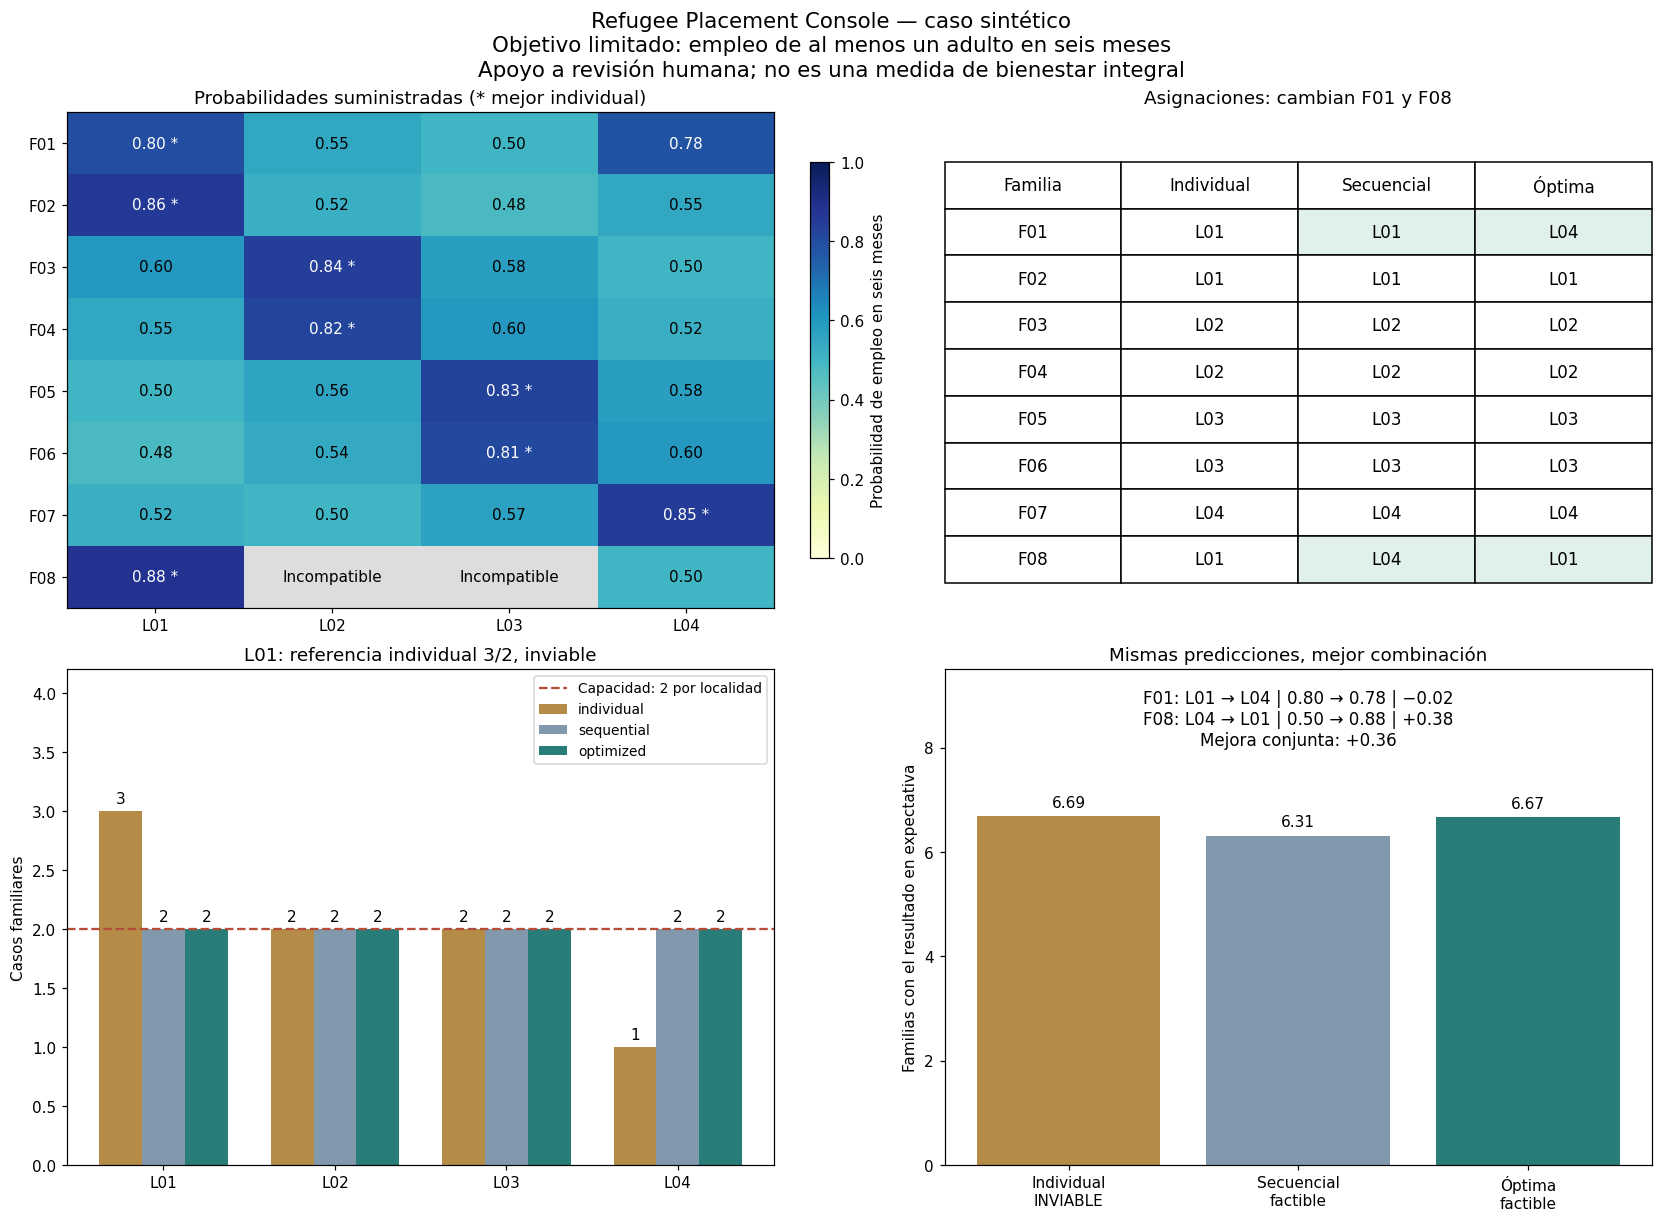

In [31]:
# Apoyo analítico sujeto a revisión humana; el objetivo no representa bienestar integral.

ax = console_axes[1, 1]
labels = ['Individual\nINVIABLE', 'Secuencial\nfactible', 'Óptima\nfactible']
bars = ax.bar(labels, assignment_comparison.total_expected_outcome, color=['#b48b47', '#8299ad', '#287d78'])
ax.bar_label(bars, fmt='%.2f', padding=4)
ax.set(ylim=(0, 9.5), ylabel='Familias con el resultado en expectativa', title='Mismas predicciones, mejor combinación')
ax.text(0.5, 0.96, 'F01: L01 → L04 | 0.80 → 0.78 | −0.02\nF08: L04 → L01 | 0.50 → 0.88 | +0.38\nMejora conjunta: +0.36', transform=ax.transAxes, ha='center', va='top', fontsize=11)
console_fig.suptitle('Refugee Placement Console — caso sintético\nObjetivo limitado: empleo de al menos un adulto en seis meses\nApoyo a revisión humana; no es una medida de bienestar integral', fontsize=14)
display(console_fig)

In [32]:
# Verificamos decisiones, capacidad, compatibilidad y explicación del intercambio.

assert len(placement_decisions) == 8 and len(location_utilization) == 12 and len(assignment_comparison) == 3
assert len(feasible_assignments) == 1260 and optimal_count == 1 and best_units == 667 and second_best == 6.38
assert np.allclose([individual_total, sequential_total, optimized_total, reverse_total], [6.69, 6.31, 6.67, 6.67])
assert sequential.location_id.tolist() == ['L01', 'L01', 'L02', 'L02', 'L03', 'L03', 'L04', 'L04']
assert optimized.location_id.tolist() == ['L04', 'L01', 'L02', 'L02', 'L03', 'L03', 'L04', 'L01']
assert optimized.location_id.value_counts().reindex(location_ids).eq(capacity).all()
assert all(compatibility_matrix.loc[f, l] for f, l in optimized.location_id.items())
assert individual_capacity.loc['L01', 'assigned_cases'] == 3 and capacity['L01'] == 2
assert assignment_comparison.feasible.tolist() == [False, True, True]
assert np.allclose(exchange.probability_change, [-0.02, 0.38]) and np.isclose(optimized_total - sequential_total, 0.36)
assert np.allclose(placement_decisions.sequential_opportunity_loss, [0] * 7 + [0.38])
assert np.allclose(placement_decisions.optimized_opportunity_loss, [0.02] + [0] * 7)
assert predictions.equals(pd.read_csv(data_dir / 'predicted_outcomes.csv'))
assert pulp.LpStatus[status] == 'Optimal'
assert np.isclose(solver_objective, exhaustive_objective)
assert solver_assignment == exhaustive_assignment
assert solver_usage.eq(capacity).all()
assert all(compatibility_matrix.loc[f, l] for f, l in solver_assignment.items())
print('Verificado: 1260 asignaciones factibles, óptimo único 6.67, HiGHS coincide con la búsqueda exhaustiva.')

Verificado: 1260 asignaciones factibles, óptimo único 6.67, HiGHS coincide con la búsqueda exhaustiva.


In [33]:
# Entregamos la comparación base y su fundamento, sin sustituirla por la sensibilidad.

submission_dir.mkdir(exist_ok=True)
placement_decisions.to_csv(submission_dir / 'placement_decisions.csv', index=False)
location_utilization.to_csv(submission_dir / 'location_utilization.csv', index=False)
assignment_comparison.to_csv(submission_dir / 'assignment_comparison.csv', index=False)
console_fig.savefig(submission_dir / 'refugee_placement_console.png', dpi=180, bbox_inches='tight', facecolor='white')
display([str(submission_dir / name) for name in ['placement_decisions.csv', 'location_utilization.csv', 'assignment_comparison.csv', 'refugee_placement_console.png']])

['../submission/placement_decisions.csv',
 '../submission/location_utilization.csv',
 '../submission/assignment_comparison.csv',
 '../submission/refugee_placement_console.png']